# Business Problem

A hedge fund is seeking alternative asset classes to invest for its investors.  The hedge fund, which will remain anonymous, is already diversified across multiple asset classes - which includes equity, fixed incomes, real estate, and commodities.  The hedge fund has observed that retail and institutional investors have generated positive returns via cryptocurrency.  As a result, this hedge fund is requesting KBO Analytics to create a model that can predict Bitcoin prices in the future.

# Data Understanding

The data for examing the aforementioned problem comes from the following source: [Coin Codex](https://coincodex.com/crypto/bitcoin/historical-data/)

Before beginning to create any type of time series model, I want to examine and become familiar with the dataset. I will conduct exploratory data analysis in order to understand the dataset attributes, which includes, but not limited to the following:

1. Number of Columns
2. Number of Rows
3. Column Names
4. Format of the data in each column

In [1]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

from sklearn.metrics import mean_squared_error

import pmdarima as pm

In [2]:
# Reading File

bitcoin_df = pd.read_csv("data/bitcoin_2014_to_2026.csv")

In [3]:
# Examining the first 5 rows of the 'bitcoin_df' dataframe

bitcoin_df.head()

,Start,End,Open,High,Low,Close,Volume,Market Cap
0,2026-06-01,2026-06-02,73868.59,73986.02,70893.96,71439.79,3.773704e+10,1.450453e+12
1,2026-05-31,2026-06-01,73876.30,74271.63,73432.95,73688.05,2.145341e+10,1.480082e+12
2,2026-05-30,2026-05-31,73450.12,74080.02,73238.96,73867.98,3.748501e+10,1.477494e+12
3,2026-05-29,2026-05-30,73669.36,74323.98,72639.16,73476.46,4.408717e+10,1.474262e+12
4,2026-05-28,2026-05-29,74545.09,74573.73,72762.76,73553.92,5.189816e+10,1.472486e+12


In [4]:
# Examining the last 5 rows of the 'bitcoin_df' dataframe

bitcoin_df.tail()

,Start,End,Open,High,Low,Close,Volume,Market Cap
4526,2014-01-09,2014-01-10,841.47,864.36,804.14,846.86,5.177652e+07,1.030407e+10
4527,2014-01-08,2014-01-09,795.99,870.68,776.18,842.72,9.721611e+07,1.019892e+10
4528,2014-01-07,2014-01-08,946.49,965.74,802.00,802.00,7.558311e+07,1.104477e+10
4529,2014-01-06,2014-01-07,936.05,1017.12,905.71,953.29,8.422901e+07,1.174604e+10
4530,2014-01-05,2014-01-06,858.55,952.40,854.52,933.53,5.139392e+07,1.087804e+10


In [5]:
# Examining the shape of the 'bitcoin_df' dataframe

bitcoin_df.shape

(4531, 8)

In [6]:
# Examining the 'bitcoin_df' dataframe

bitcoin_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4531 entries, 0 to 4530
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Start       4531 non-null   object 
 1   End         4531 non-null   object 
 2   Open        4531 non-null   float64
 3   High        4531 non-null   float64
 4   Low         4531 non-null   float64
 5   Close       4531 non-null   float64
 6   Volume      4531 non-null   float64
 7   Market Cap  4531 non-null   float64
dtypes: float64(6), object(2)
memory usage: 283.3+ KB


In [7]:
# Obtaining descriptive analytics of the 'bitcoin_df' dataframe

bitcoin_df.describe()

,Open,High,Low,Close,Volume,Market Cap
count,4531.000000,4531.000000,4531.000000,4531.000000,4.531000e+03,4.531000e+03
mean,27003.688488,27526.497384,26456.890629,27021.663436,3.521488e+10,5.232794e+11
std,32160.258870,32680.823086,31612.563903,32168.110924,3.886304e+10,6.392699e+11
min,178.103000,211.731000,171.510000,178.795000,2.688736e+06,2.690697e+09
25%,1012.590000,1043.855000,991.586500,1016.730000,2.049405e+08,1.651487e+10
50%,10300.390061,10474.365680,10008.252865,10313.443526,2.374011e+10,1.832743e+11
75%,43288.930000,44145.078950,42490.183960,43326.830000,5.926236e+10,8.370000e+11
max,124696.000000,126025.000000,123164.000000,124735.000000,2.121958e+11,2.479741e+12


In [8]:
# Examining whether or not there is missing data

bitcoin_df.isna().sum()

Start         0
End           0
Open          0
High          0
Low           0
Close         0
Volume        0
Market Cap    0
dtype: int64

In [9]:
# Examining whether or not there are duplicates

bitcoin_df.duplicated().sum()

0

# Data Preparation

I have completed my exploratory data analysis (EDA).  Based on the analytics, the dataset contains a total of 4,531 rows.  There are a total of 8 columns, which are the following:

- *Start* - Start Date
- *End* - End Date
- *Open* - Opening (Bitcoin) Price (for the day)
- *High* - Highest (Bitcoin) Price (for the day)
- *Low* - Lowest (Bitcoin) Price (for the day)
- *Close* - Closing (Bitcoin) Price (for the day)
- *Volume* - 24-hour (Bitcoin) trading volume (for the day)
- *Market Cap* - Market capitalization (of Bitcoin) for the day

I will use the Start Date and Closing Price to create the time series models.  As a result, I will remove the following columns: *End*, *Open*, *High*, *Low*, *Volume*, and *Market Cap*.

I also noticed that the first row of data pertains to a Start Date and End Date of January 1st, 2026; and January 2nd, 2026, respectively.  The last row of data pertains to a Start Date and End Date of January 5th, 2014; and January 6th, 2014.  I will need to invert the row order of the dataset before proceeding to the modeling stage.

The *Start* column is in a string format.  I want to convert the aforementioned column to a date format since the column is capturing time.

Finally, I will relabel the columns.  I will rename the *Start* column to *Date*.  I will also rename the *Close* column to *Price*.

In [10]:
# Removing the 'End', 'Open', 'High', 'Low', 'Volume', 'Market Cap' columns from the dataset

bitcoin_df.drop(columns=['End', 'Open', 'High', 'Low', 'Volume', 'Market Cap'], inplace=True)

In [11]:
# Checking whether or not the columns - 'End', 'Open', 'High', 'Low', 'Volume', 'Market Cap' - have been removed

bitcoin_df.head()

,Start,Close
0,2026-06-01,71439.79
1,2026-05-31,73688.05
2,2026-05-30,73867.98
3,2026-05-29,73476.46
4,2026-05-28,73553.92


In [12]:
# Converting the 'Start' column to time format

bitcoin_df['Start'] = pd.to_datetime(bitcoin_df['Start'])

In [13]:
# Checking whether or not the format of the 'Start' column has been converted to time format

bitcoin_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4531 entries, 0 to 4530
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Start   4531 non-null   datetime64[ns]
 1   Close   4531 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 70.9 KB


In [14]:
# Relabeling the 'Start' column to 'Date

bitcoin_df.rename(columns = {'Start':'Date'}, inplace=True)

In [15]:
# Checking whether or not the 'Start' column has been renamed to 'Date'

bitcoin_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4531 entries, 0 to 4530
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    4531 non-null   datetime64[ns]
 1   Close   4531 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 70.9 KB


In [16]:
# Relabeling the 'Close' column to 'Price'

bitcoin_df.rename(columns = {'Close':'Price'}, inplace=True)

In [17]:
# Checking whether or not the 'Close' columns has been renamed to 'Price'

bitcoin_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4531 entries, 0 to 4530
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    4531 non-null   datetime64[ns]
 1   Price   4531 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 70.9 KB


# Modeling

The data preparation state is complete.  I will transition towards the modeling stage.  To be specific, I will create a series of four time series models, and select the best one to predict Bitcoin prices in the future.  The four categoeis of times series models are the following:


**1. Naive Forecast**  This time series model uses the previous data points to predict the next data points.  The Naive forecast serves as a baseline model of comparison for other time series models.

**2. Moving Average**  This time series model is based on past forecast errors instead of the past data points.  The forecast errors can be referred to as residuals or *shocks*.  Within time series modeling, the forecast errors last for a finite error of steps and eventually disappear.  The objective of creating a moving average time series model is to create another baseline model of comparison.

**3. ARIMA**  The ARIMA Model is more complex than the Naive Forecast and Moving Average Models.  There are three variables that make up the ARIMA model, which are the following:

- Auto Regressive (AR) (denoted as *p*) - in the same manner as the Naive Forecast, this variable references the number of lagged data points to forecast future data points.  As an example, if one lagged data point is utilized in the forecast, then *p* is equal to 1.


- Stationarity (I) (denoted as *d*) - this references the amount of differencing required to remove non-stationary trends.  In order to successfully create an ARIMA model, the data needs to be stationary.  In other words, the data needs to have a constant average, constant variance (the spread between the actual data point and forecasted data point remains constant), and constant autocorrelation (the relationship between past observations and current observations only depends on time).  Differencing is the actual transformation that turns non-stationary data into stationary data.


- Moving Average (MA) (denoted as *q*) - this is the same Moving Average as highlighted in the aforementioned Moving Average Model section.

In summary, I will manually attempt to create an ARIMA model based on the following three values:

- *p*: Trend Autoregression Order
- *d*: Trend Difference Order
- *q*: Trend Moving Average Order

**4. Auto-ARIMA** I will create another set of time series models based on the Auto-ARIMA function within the Statsmodel library. 

## Naive Forecast ##

### Naive Forecast ###

In [18]:
# Creating a copy of the 'bitcoin_df' dataframe

bitcoin_df_naive = bitcoin_df.copy()

In [19]:
# Checking to determine whether or not the 'bitcoin_df_naive' dataframe has been created

bitcoin_df_naive.head()

,Date,Price
0,2026-06-01,71439.79
1,2026-05-31,73688.05
2,2026-05-30,73867.98
3,2026-05-29,73476.46
4,2026-05-28,73553.92


In [20]:
# Function to convert date column to datetime, and set the date as the index

def date_to_datetime_set_index(df, date_column):

    # Convert date column to datetime
    
    df[date_column] = pd.to_datetime(df[date_column])
    
    # Sort chronologically
    
    df = df.sort_values(by=date_column)
    
    # Set date as the index
    
    df = df.set_index(date_column)
    
    return df

In [21]:
# Utilizing the 'date_to_datetime_set_index' function on the 'bitcoin_df_naive' dataframe

bitcoin_df_naive = date_to_datetime_set_index(bitcoin_df_naive, 'Date')

In [22]:
# Examining whether or not the 'date_to_datetime_set_index' function was executed successfully

bitcoin_df_naive.head()

,Price
Date,
2014-01-05,933.53
2014-01-06,953.29
2014-01-07,802.00
2014-01-08,842.72
2014-01-09,846.86


In [23]:
# Creating a new column 'Price_Previous'

bitcoin_df_naive['Price_Previous'] = bitcoin_df_naive['Price'].shift(1)

In [24]:
# Examining the new column 'Price_Lag'

bitcoin_df_naive.head()

,Price,Price_Previous
Date,,
2014-01-05,933.53,NaN
2014-01-06,953.29,933.53
2014-01-07,802.00,953.29
2014-01-08,842.72,802.00
2014-01-09,846.86,842.72


In [25]:
# Creating the train and test set from the 'bitcoin_df_naive' dataframe

# The last 360 data points are going to be the test set

new_train_naive, new_test_naive = bitcoin_df_naive[1:bitcoin_df_naive.shape[0]-360], bitcoin_df_naive[bitcoin_df_naive.shape[0]-360:]

In [26]:
# Examining the train set

new_train_naive.head()

,Price,Price_Previous
Date,,
2014-01-06,953.29,933.53
2014-01-07,802.00,953.29
2014-01-08,842.72,802.00
2014-01-09,846.86,842.72
2014-01-10,868.48,846.86


In [27]:
# Examining the test set

new_test_naive.head()

,Price,Price_Previous
Date,,
2025-06-07,105603.0,104302.0
2025-06-08,105661.0,105603.0
2025-06-09,110193.0,105661.0
2025-06-10,110229.0,110193.0
2025-06-11,108682.0,110229.0


In [28]:
# Creating the X-train and y-train for the train set

X_train_naive, y_train_naive = new_train_naive['Price_Previous'], new_train_naive['Price']

In [29]:
# Examining the "X_train_naive" data

X_train_naive.head()

Date
2014-01-06    933.53
2014-01-07    953.29
2014-01-08    802.00
2014-01-09    842.72
2014-01-10    846.86
Name: Price_Previous, dtype: float64

In [30]:
# Creating the X-test and y-test from the test set

X_test_naive, y_test_naive = new_test_naive['Price_Previous'], new_test_naive['Price']

In [31]:
# Examining the 'X_test' set

X_test_naive.head()

Date
2025-06-07    104302.0
2025-06-08    105603.0
2025-06-09    105661.0
2025-06-10    110193.0
2025-06-11    110229.0
Name: Price_Previous, dtype: float64

In [32]:
# Examining the 'y_test' set

y_test_naive.head()

Date
2025-06-07    105603.0
2025-06-08    105661.0
2025-06-09    110193.0
2025-06-10    110229.0
2025-06-11    108682.0
Name: Price, dtype: float64

In [33]:
# Creating predictions for the Naive Forecast Model

predictions_naive = X_test_naive.copy()

In [34]:
# Calculating RMSE for the Naive Forecast

rmse_naive = mean_squared_error(y_test_naive, predictions_naive, squared=False)

print(rmse_naive)

1950.8802887530742


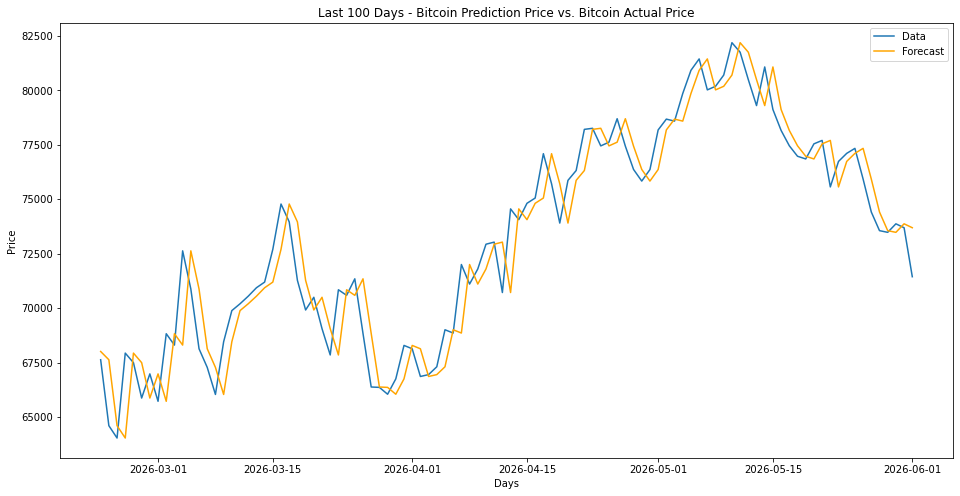

In [35]:
# Plotting the data, or 'y_test_naive', against the forecast, or 'predictions_naive'

# Examining a plot of the last 100 observations

plt.figure(figsize=(16,8)) # Width, Height in Inches

plt.plot(y_test_naive[-100:], label='Data') # Can also use 'y_test_naive[260:360]' to examine the last 100 observations
plt.plot(predictions_naive[-100:], label='Forecast', color='orange') # Can also use 'X_test_naive[260:360]' to examine the last 100 observations


plt.title("Last 100 Days - Bitcoin Prediction Price vs. Bitcoin Actual Price")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.show()

### Naive Forecast (with Log Transformation) ###

In [36]:
# Creating another copy of the 'bitcoin_df' dataframe

bitcoin_df_naive_log = bitcoin_df.copy()

In [37]:
# Checking to determine whether or not the 'bitcoin_df_naive_log' dataframe has been created

bitcoin_df_naive_log.head()

,Date,Price
0,2026-06-01,71439.79
1,2026-05-31,73688.05
2,2026-05-30,73867.98
3,2026-05-29,73476.46
4,2026-05-28,73553.92


In [38]:
# Applying Log Transformation to the 'Price' column

bitcoin_df_naive_log['Price'] = np.log(bitcoin_df_naive_log['Price'])

In [39]:
# Checking whether or not the Log Transformation has been applied to the 'Price' column

bitcoin_df_naive_log.head()

,Date,Price
0,2026-06-01,11.176610
1,2026-05-31,11.207596
2,2026-05-30,11.210035
3,2026-05-29,11.204720
4,2026-05-28,11.205774


In [40]:
# Utilizing the 'date_to_datetime_set_index' function on the 'bitcoin_df_naive_log' dataframe

bitcoin_df_naive_log = date_to_datetime_set_index(bitcoin_df_naive_log, 'Date')

In [41]:
# Examining whether or not the 'date_to_datetime_set_index' function was executed successfully

bitcoin_df_naive_log.head()

,Price
Date,
2014-01-05,6.838973
2014-01-06,6.859919
2014-01-07,6.687109
2014-01-08,6.736635
2014-01-09,6.741535


In [42]:
# Creating a new column 'Price_Previous'

bitcoin_df_naive_log['Price_Previous'] = bitcoin_df_naive_log['Price'].shift(1)

In [43]:
# Examining the new column 'Price_Previous'

bitcoin_df_naive_log.head()

,Price,Price_Previous
Date,,
2014-01-05,6.838973,NaN
2014-01-06,6.859919,6.838973
2014-01-07,6.687109,6.859919
2014-01-08,6.736635,6.687109
2014-01-09,6.741535,6.736635


In [44]:
# Creating the train and test set from the 'bitcoin_df_naive_log' dataframe

# The last 360 data points are going to be the test set

new_train_naive_log, new_test_naive_log = bitcoin_df_naive_log[1:bitcoin_df_naive_log.shape[0]-360], bitcoin_df_naive_log[bitcoin_df_naive_log.shape[0]-360:]

In [45]:
# Examining the train set

new_train_naive_log.head()

,Price,Price_Previous
Date,,
2014-01-06,6.859919,6.838973
2014-01-07,6.687109,6.859919
2014-01-08,6.736635,6.687109
2014-01-09,6.741535,6.736635
2014-01-10,6.766745,6.741535


In [46]:
# Examining the test set

new_test_naive_log.head()

,Price,Price_Previous
Date,,
2025-06-07,11.567442,11.555046
2025-06-08,11.567991,11.567442
2025-06-09,11.609989,11.567991
2025-06-10,11.610315,11.609989
2025-06-11,11.596181,11.610315


In [47]:
# Creating the X-train and y-train for the train set

X_train_naive_log, y_train_naive_log = new_train_naive_log['Price_Previous'], new_train_naive_log['Price']

In [48]:
# Creating the X-test and y-test from the test set

X_test_naive_log, y_test_naive_log = new_test_naive_log['Price_Previous'], new_test_naive_log['Price']

In [49]:
# Examining the 'X_test' set

X_test_naive_log.head()

Date
2025-06-07    11.555046
2025-06-08    11.567442
2025-06-09    11.567991
2025-06-10    11.609989
2025-06-11    11.610315
Name: Price_Previous, dtype: float64

In [50]:
# Examining the 'y_test' set

y_test_naive.head()

Date
2025-06-07    105603.0
2025-06-08    105661.0
2025-06-09    110193.0
2025-06-10    110229.0
2025-06-11    108682.0
Name: Price, dtype: float64

In [51]:
# Creating predictions for the Naive Forecast Model with Log Transformation

predictions_naive_log = X_test_naive_log.copy()

In [52]:
# Calculate Root Mean Square Error (RMSE) of the Naive Forecast Model with Log Transformation

rmse_naive_log = mean_squared_error(y_test_naive_log, predictions_naive_log, squared=False)

print(rmse_naive_log)


0.022194514861663052


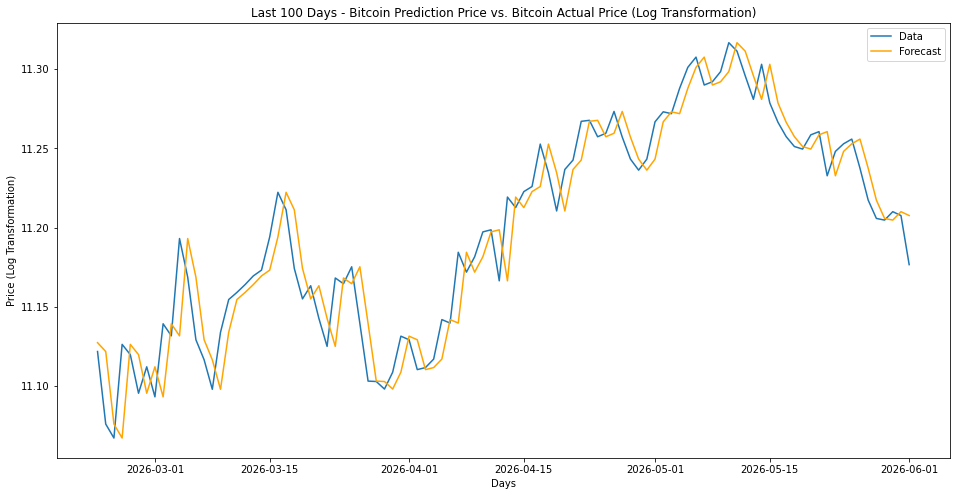

In [53]:
# Plotting the predictions, or 'X_test_naive_log', against the actual results, or 'y_test_naive_log'

# Examinning a plot of the last 100 observations

plt.figure(figsize=(16,8)) # Width, Height in Inches

plt.plot(y_test_naive_log[-100:], label='Data') # Can also use 'y_test_naive_log[260:360]' to examine the last 100 observations
plt.plot(predictions_naive_log[-100:], label='Forecast', color='orange') # Can also use 'X_test_naive_log[260:360]' to examine the last 100 observations


plt.title("Last 100 Days - Bitcoin Prediction Price vs. Bitcoin Actual Price (Log Transformation)")
plt.xlabel("Days")
plt.ylabel("Price (Log Transformation)")
plt.legend()
plt.show()

### Naive Forecast | Conclusion ###

In [54]:
# Printing RMSE numbers for the Noive Forecast and Naive Forecast with Log Transformation Models

print(f"RMSE for Naive Forecast Model: {rmse_naive:.4f}")

print(f"RMSE for Naive Forecast Model with Log Transformation: {rmse_naive_log:.4f}")

RMSE for Naive Forecast Model: 1950.8803
RMSE for Naive Forecast Model with Log Transformation: 0.0222


The RMSE numbers for the Niave Forecast and Naive Forecast with Log Transformation Models are the following:

- RMSE for Naive Forecast Model: 1950.8803
- RMSE for Naive Forecast Model with Log Transformation: 0.0222

Since the Naive Forecast with Log Transformation has the smaller RMSE number, it is the best performing Naive Forecast Model.

## Moving Average ##

I have concluded create Naive Forecast models.  I want to create another set of time series models - Moving Average - which will serve as another baseline.

The Moving Average models will be the following:

- Moving Average (q=2)
- Moving Average (q=5)
- Moving Average with Log Transformation (q=2)
- Moving Average with Log Transformtion (q=5)

### Moving Average (d=2) ###

In [55]:
# Creating a dataframe for Moving Average (d=2)

bitcoin_df_ma_2 = bitcoin_df.copy()

In [56]:
# Checking to determine whether or not the new dataframe has been created

bitcoin_df_ma_2.head()

,Date,Price
0,2026-06-01,71439.79
1,2026-05-31,73688.05
2,2026-05-30,73867.98
3,2026-05-29,73476.46
4,2026-05-28,73553.92


In [57]:
# Creating a function for the train and test set

def moving_average_train_test(df):
    
    # Train / Test Split
    Ntest = 360

    # Convert Date column to datetime
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Set Date as the Index
    df = df.set_index('Date')
    
    # Make sure data is oldest to newest
    df = df.sort_index()
    
    # Setting index frequency to daily
    df = df.asfreq('D')

    # Train / Test Split
    train = df.iloc[:-Ntest]
    test = df.iloc[-Ntest:]

    # Index masks
    train_idx = df.index <= train.index[-1]
    test_idx = df.index > test.index[-1]
    
    return train, test, train_idx, test_idx

In [58]:
# Creating the train and test set for the 'Bitcoin Moving Average (q=2)' dataframe

bitcoin_df_ma_2_train, bitcoin_df_ma_2_test, bitcoin_df_ma_2_train_idx, bitcoin_df_ma_2_test_idx = moving_average_train_test(bitcoin_df_ma_2)

In [59]:
# Creating ARIMA model for the 'Bitcoin Moving Average (q=2)' dataframe

arima_ma_2 = ARIMA(bitcoin_df_ma_2_train, order=(0,0,2))

In [60]:
# Fit the model to the 'Bitcoin Moving Average (q=2)' data

arima_ma_2_result = arima_ma_2.fit()

C:\Users\16467\anaconda3\envs\learn-env\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [61]:
# Model Summary of the 'Bitcoin Moving Average (q=2)' Model

arima_ma_2_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Price   No. Observations:                 4171
Model:                 ARIMA(0, 0, 2)   Log Likelihood              -43264.814
Date:                Thu, 23 Jul 2026   AIC                          86537.628
Time:                        11:36:42   BIC                          86562.971
Sample:                    01-05-2014   HQIC                         86546.592
                         - 06-06-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.124e+04    436.749     48.632      0.000    2.04e+04    2.21e+04
ma.L1          1.7047      0.004    427.002      0.000       1.697       1.713
ma.L2          0.8831      0.004    220.326      0.000       0.875       0.891
sigma2       5.98e+07      0.167   3.57e+08      0.000    5.98e+07    5.98e+07
===================================================================================
Ljung-Box (L1) (Q):                2456.50   Jarque-Bera (JB):              3399.59
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               3.82   Skew:                             1.73
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.76
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.88e+22. Standard errors may be unstable.
"""

In [62]:
# Using the 'Bitcoin Moving Average (q=2)' Model to forecast

prediction_result_arima_ma_2 = arima_ma_2_result.forecast(steps=360)

In [63]:
# Calculate Root Mean Square Error (RMSE) for the 'Bitcoin Moving Average (q=2)' Model

rmse_arima_ma_2 = mean_squared_error(bitcoin_df_ma_2_test, prediction_result_arima_ma_2, squared=False)

print(rmse_arima_ma_2)

74823.35986236691


In [64]:
# Creating a function to plot the predictions against the actual results

def plot_model(Actual_Data, Prediction_Results, Title):

    plt.figure(figsize=(16,8)) # Width, Height in Inches

    # Plot of the Actual Data
    plt.plot(Actual_Data, label='Data') 
    
    # Plot of the Prediction Data
    plt.plot(Prediction_Results, color='orange', label='Forecast') 

    # Title of the Plot
    plt.title(Title) 
    
    # Label on the x-axis
    plt.xlabel("Days") 
    
    # Label on the y-axis
    plt.ylabel("Price") 
    
    # Legend
    plt.legend()
        
    return plt.show()

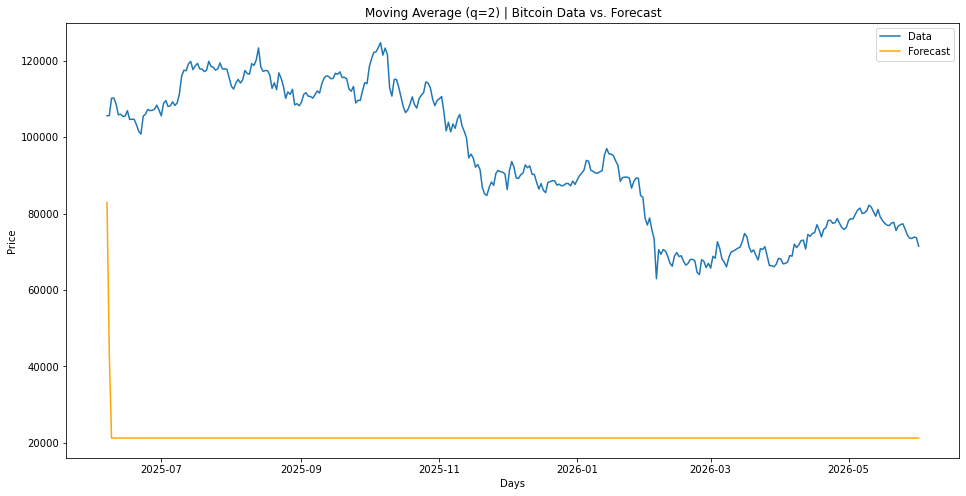

In [65]:
# Plotting the predictions against the actual results for the 'Bitcoin Moving Average (q=2)' Model

plot_model(bitcoin_df_ma_2_test, prediction_result_arima_ma_2, Title='Moving Average (q=2) | Bitcoin Data vs. Forecast')

### Moving Average (q=5) ###

In [66]:
# Creating a dataframe for Moving Average (d=5)

bitcoin_df_ma_5 = bitcoin_df.copy()

In [67]:
# Checking to determine whether or not the new dataframe has been created

bitcoin_df_ma_5.head()

,Date,Price
0,2026-06-01,71439.79
1,2026-05-31,73688.05
2,2026-05-30,73867.98
3,2026-05-29,73476.46
4,2026-05-28,73553.92


In [68]:
# Creating the train and test set for the 'Bitcoin Moving Average (q=5)' dataframe

bitcoin_df_ma_5_train, bitcoin_df_ma_5_test, bitcoin_df_ma_5_train_idx, bitcoin_df_ma_5_test_idx = moving_average_train_test(bitcoin_df_ma_5)

In [69]:
# Creating ARIMA model for the 'Bitcoin Moving Average (q=5)' dataframe

arima_ma_5 = ARIMA(bitcoin_df_ma_5_train, order=(0,0,5))

In [70]:
# Fit the model to the 'Bitcoin Moving Average (q=5)' data

arima_ma_5_result = arima_ma_5.fit()

C:\Users\16467\anaconda3\envs\learn-env\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\16467\anaconda3\envs\learn-env\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [71]:
# Model Summary of the 'Bitcoin Moving Average (q=5)' Model

arima_ma_5_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Price   No. Observations:                 4171
Model:                 ARIMA(0, 0, 5)   Log Likelihood              -45211.998
Date:                Thu, 23 Jul 2026   AIC                          90437.995
Time:                        11:36:48   BIC                          90482.346
Sample:                    01-05-2014   HQIC                         90453.683
                         - 06-06-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.124e+04   2806.465      7.568      0.000    1.57e+04    2.67e+04
ma.L1          0.5785      0.066      8.707      0.000       0.448       0.709
ma.L2          0.9927      0.076     13.063      0.000       0.844       1.142
ma.L3          0.9056      0.072     12.591      0.000       0.765       1.047
ma.L4          0.0161      0.065      0.247      0.805      -0.112       0.144
ma.L5          0.5242      0.080      6.552      0.000       0.367       0.681
sigma2      3.169e+08      0.130   2.43e+09      0.000    3.17e+08    3.17e+08
===================================================================================
Ljung-Box (L1) (Q):                 567.90   Jarque-Bera (JB):              2170.37
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               7.40   Skew:                             1.49
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.90
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.09e+25. Standard errors may be unstable.
"""

In [72]:
# Using the 'Bitcoin Moving Average (q=5)' Model to forecast

prediction_result_arima_ma_5 = arima_ma_5_result.forecast(steps=360)

In [73]:
# Calculate Root Mean Square Error (RMSE) for the 'Bitcoin Moving Average (q=5)' Model

rmse_arima_ma_5 = mean_squared_error(bitcoin_df_ma_5_test, prediction_result_arima_ma_5, squared=False)

print(rmse_arima_ma_5)

74581.96632561137


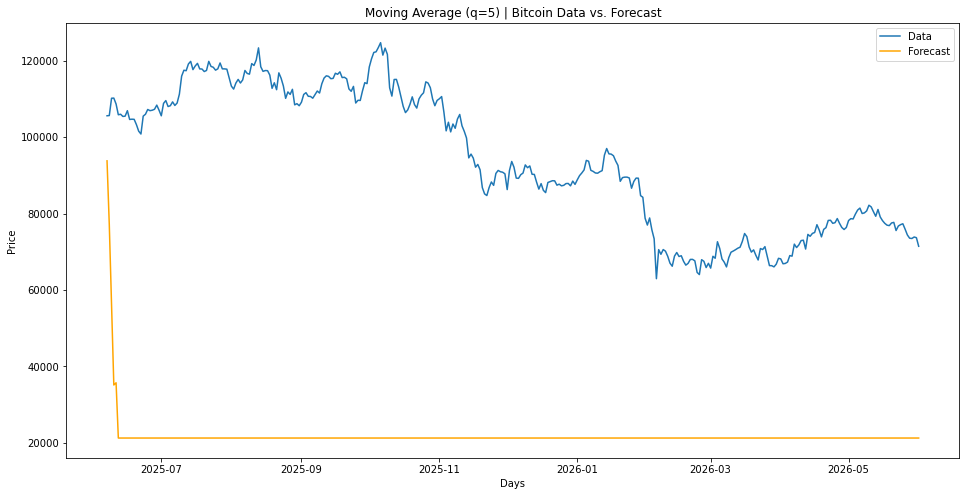

In [74]:
# Plotting the predictions against the actual results for the 'Bitcoin Moving Average (q=5) Model

plot_model(bitcoin_df_ma_5_test, prediction_result_arima_ma_5, Title='Moving Average (q=5) | Bitcoin Data vs. Forecast')

### Moving Average (q=2) with Log Transformation  ###

In [75]:
# Creating a dataframe for 'Moving Average (q=2)' with Log Transformation

bitcoin_df_ma_2_log = bitcoin_df.copy()

In [76]:
# Checking to determine whether or not the new dataframe has been created

bitcoin_df_ma_2_log.head()

,Date,Price
0,2026-06-01,71439.79
1,2026-05-31,73688.05
2,2026-05-30,73867.98
3,2026-05-29,73476.46
4,2026-05-28,73553.92


In [77]:
# Applying Log Transformation to the 'Price' column

bitcoin_df_ma_2_log['Price'] = np.log(bitcoin_df_ma_2_log['Price'])

In [78]:
# Checking to determine whether or not the Log Transformation has been completed

bitcoin_df_ma_2_log.head()

,Date,Price
0,2026-06-01,11.176610
1,2026-05-31,11.207596
2,2026-05-30,11.210035
3,2026-05-29,11.204720
4,2026-05-28,11.205774


In [79]:
# Creating the train and test set for the 'Bitcoin Moving Average (q=2)' Model with Log Transformation

bitcoin_df_ma_2_log_train, bitcoin_df_ma_2_log_test, bitcoin_df_ma_2_log_train_idx, bitcoin_df_ma_2_log_test_idx = moving_average_train_test(bitcoin_df_ma_2_log)

In [80]:
# Creating the 'Bitcoin Moving Average (q=2)' Model with Log Transformation

arima_ma_2_log = ARIMA(bitcoin_df_ma_2_log_train, order=(0,0,2))

In [81]:
# Fit the model to the 'Bitcoin Moving Average (q=2)' with Log Transformation data

arima_ma_2_log_result = arima_ma_2_log.fit()

In [82]:
# Model Summary of the 'Bitcoin Moving Average (q=2)' Model with Log Transformation

arima_ma_2_log_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Price   No. Observations:                 4171
Model:                 ARIMA(0, 0, 2)   Log Likelihood               -3248.232
Date:                Thu, 23 Jul 2026   AIC                           6504.464
Time:                        11:36:51   BIC                           6529.807
Sample:                    01-05-2014   HQIC                          6513.428
                         - 06-06-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.7672      0.033    264.791      0.000       8.702       8.832
ma.L1          1.8061      0.006    297.506      0.000       1.794       1.818
ma.L2          0.9436      0.006    155.982      0.000       0.932       0.956
sigma2         0.2775      0.010     27.744      0.000       0.258       0.297
===================================================================================
Ljung-Box (L1) (Q):                3167.83   Jarque-Bera (JB):               297.59
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.62   Skew:                            -0.32
Prob(H) (two-sided):                  0.00   Kurtosis:                         1.86
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [83]:
# Using the 'Bitcoin Moving Average (q=2)' Model with Log Transformation to forecast

prediction_result_arima_ma_2_log = arima_ma_2_log_result.forecast(steps=360)

In [84]:
# Calculate Root Mean Square Error (RMSE) for the 'Bitcoin Moving Average (q=2)' Model with Log Transformation

rmse_arima_ma_2_log = mean_squared_error(bitcoin_df_ma_2_log_test, prediction_result_arima_ma_2_log, squared=False)

print(rmse_arima_ma_2_log)

2.6663426367954925


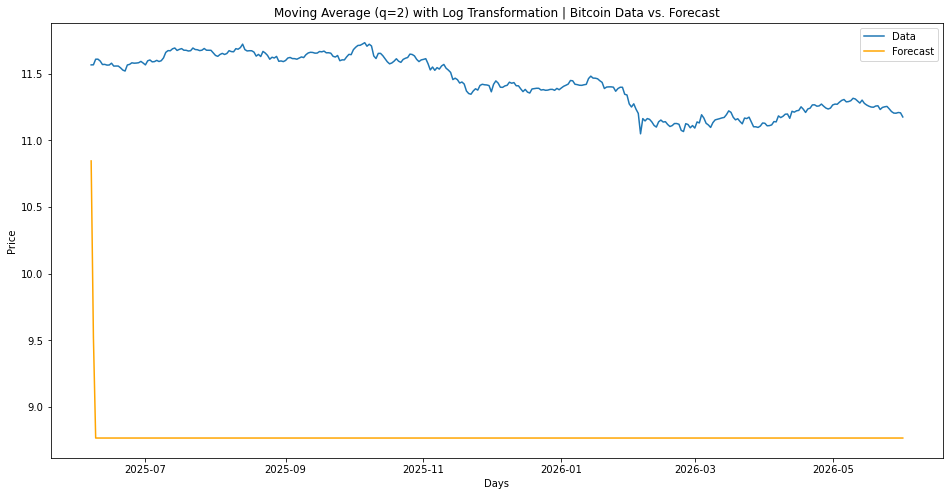

In [85]:
# Plotting the predictions against the actual results for the 'Bitcoin Moving Average (q=2)' Model with Log Transformation

plot_model(bitcoin_df_ma_2_log_test, prediction_result_arima_ma_2_log, Title='Moving Average (q=2) with Log Transformation | Bitcoin Data vs. Forecast')

### Moving Average with Log Transformation (q=5) ###

In [86]:
# Creating a dataframe for 'Moving Average (q=5)'' with Log Transformation

bitcoin_df_ma_5_log = bitcoin_df.copy()

In [87]:
# Checking to determine whether or not the new dataframe has been created

bitcoin_df_ma_5_log.head()

,Date,Price
0,2026-06-01,71439.79
1,2026-05-31,73688.05
2,2026-05-30,73867.98
3,2026-05-29,73476.46
4,2026-05-28,73553.92


In [88]:
# Applying Log Transformation to the 'Price' column

bitcoin_df_ma_5_log['Price'] = np.log(bitcoin_df_ma_5_log['Price'])

In [89]:
# Checking to determine whether or not the Log Transformation has been completed

bitcoin_df_ma_5_log.head()

,Date,Price
0,2026-06-01,11.176610
1,2026-05-31,11.207596
2,2026-05-30,11.210035
3,2026-05-29,11.204720
4,2026-05-28,11.205774


In [90]:
# Creating the train and test set for the 'Bitcoin Moving Average (q=5)' with Log Transformation dataframe

bitcoin_df_ma_5_log_train, bitcoin_df_ma_5_log_test, bitcoin_df_ma_5_log_train_idx, bitcoin_df_ma_5_log_test_idx = moving_average_train_test(bitcoin_df_ma_5_log)

In [91]:
# Creating the 'Bitcoin Moving Average (q=5)' Model with Log Transformation Model

arima_ma_5_log = ARIMA(bitcoin_df_ma_5_log_train, order=(0,0,5))

In [92]:
# Fit the model to the 'Bitcoin Moving Average (q=5)' with Log Transformation data

arima_ma_5_log_result = arima_ma_5_log.fit()

C:\Users\16467\anaconda3\envs\learn-env\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [93]:
# Model Summary of the 'Bitcoin Moving Average (q=5)' Model with Log Transformation

arima_ma_5_log_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Price   No. Observations:                 4171
Model:                 ARIMA(0, 0, 5)   Log Likelihood                1409.624
Date:                Thu, 23 Jul 2026   AIC                          -2805.247
Time:                        11:36:55   BIC                          -2760.896
Sample:                    01-05-2014   HQIC                         -2789.559
                         - 06-06-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.7674      0.037    235.469      0.000       8.694       8.840
ma.L1          2.5591      0.010    244.034      0.000       2.539       2.580
ma.L2          3.6854      0.024    152.159      0.000       3.638       3.733
ma.L3          3.4668      0.031    112.750      0.000       3.407       3.527
ma.L4          2.1108      0.024     86.961      0.000       2.063       2.158
ma.L5          0.6836      0.011     63.491      0.000       0.662       0.705
sigma2         0.0297      0.001     39.701      0.000       0.028       0.031
===================================================================================
Ljung-Box (L1) (Q):                 857.47   Jarque-Bera (JB):                69.45
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.59   Skew:                            -0.31
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.06
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [94]:
# Using the 'Moving Average (q=5)' Model with Log Transformation to forecast

prediction_result_arima_ma_5_log = arima_ma_5_log_result.forecast(steps=360)

In [95]:
# Calculate Root Mean Square Error (RMSE) for the 'Bitcoin Moving Average (q=5)' Model with Log Transformation

rmse_arima_ma_5_log = mean_squared_error(bitcoin_df_ma_5_log_test, prediction_result_arima_ma_5_log, squared=False)

print(rmse_arima_ma_5_log)

2.6584391149876394


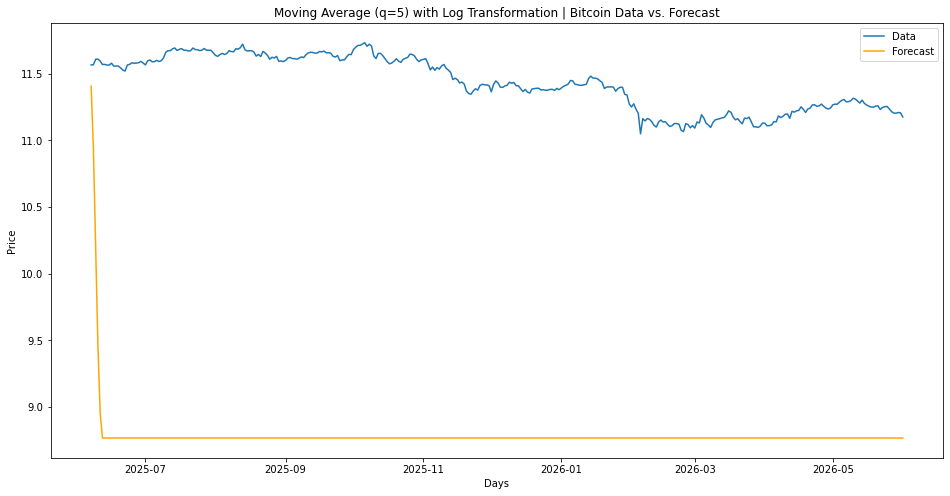

In [96]:
# Plotting the predictions against the actual results for the 'Bitcoin Moving Average (q=5)' Model with Log Transformation

plot_model(bitcoin_df_ma_5_log_test, prediction_result_arima_ma_5_log, Title='Moving Average (q=5) with Log Transformation | Bitcoin Data vs. Forecast')

## ARIMA ##

### ARIMA ###

In [97]:
# Creating a dataframe for ARIMA model

bitcoin_arima = bitcoin_df.copy()

In [98]:
# Checking to determine whether or not the new dataframe has been created

bitcoin_arima.head()

,Date,Price
0,2026-06-01,71439.79
1,2026-05-31,73688.05
2,2026-05-30,73867.98
3,2026-05-29,73476.46
4,2026-05-28,73553.92


In [99]:
# Creating a dataframe of the "bitcoin_arima" dataframe in order to examine the p,d,q variables that are required to create the ARIMA Model

bitcoin_arima_diff = bitcoin_arima.copy()

In [100]:
# Function to convert date column to datetime, and set the date as the index

def date_to_datetime_set_index(df, date_column):

    # Convert date column to datetime
    
    df[date_column] = pd.to_datetime(df[date_column])
    
    # Sort chronologically
    
    df = df.sort_values(by=date_column)
    
    # Set date as the index
    
    df = df.set_index(date_column)
    
    return df

In [101]:
# Utilizing the 'date_to_datetime_set_index' function on the 'bitcoin_arima' dataframe

bitcoin_arima_diff = date_to_datetime_set_index(bitcoin_arima_diff, 'Date')

In [102]:
# Examining whether or not the 'date_to_datetime_set_index' function was executed successfully

bitcoin_arima_diff.head()

,Price
Date,
2014-01-05,933.53
2014-01-06,953.29
2014-01-07,802.00
2014-01-08,842.72
2014-01-09,846.86


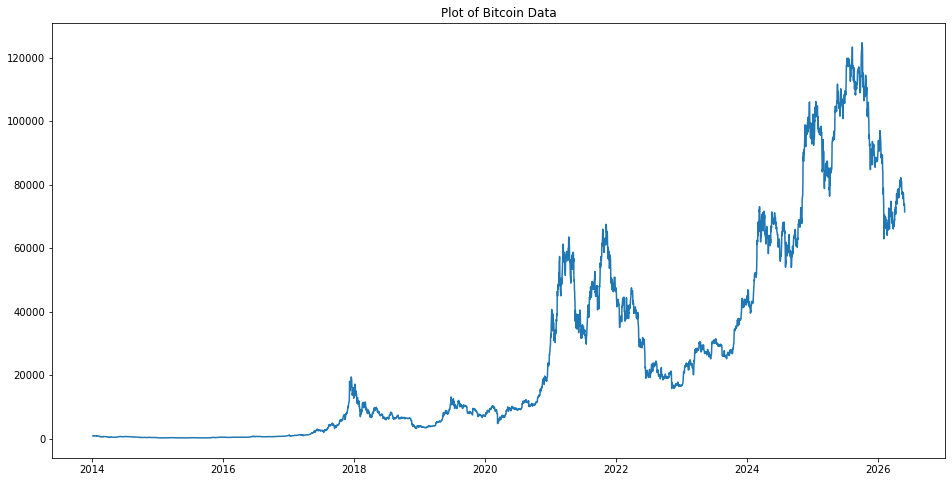

In [103]:
# Examining a plot of the Price column to determine how much to difference the data

plt.figure(figsize=(16, 8))

plt.plot(bitcoin_arima_diff['Price'])

plt.title("Plot of Bitcoin Data")
           
plt.show()

Based on the plot, Bitcoin prices have an upward trend.  However, the trend is not linear.  As a result, I am going to difference the data two times.

In [104]:
# Applying second-order differencing to the 'Price' column

bitcoin_arima_diff['Price'] = bitcoin_arima_diff['Price'].diff().diff()

In [105]:
# Examining whether or not the 'Price' column has been differenced

bitcoin_arima_diff.head()

,Price
Date,
2014-01-05,NaN
2014-01-06,NaN
2014-01-07,-171.05
2014-01-08,192.01
2014-01-09,-36.58


In [106]:
# Drop the rows with no data in the 'Price' column

bitcoin_arima_diff.dropna(inplace=True)

In [107]:
# Examining whether or not the rows with no data in the 'bitcoin_arima_diff' dataframe have been dropped

bitcoin_arima_diff.head()

,Price
Date,
2014-01-07,-171.05
2014-01-08,192.01
2014-01-09,-36.58
2014-01-10,17.48
2014-01-11,23.85


In [108]:
# Performing a Dicky Fuller test to determine whether or not the 'bitcoin_arima_dff' dataframe has stationarity

bitcoin_arima_diff_adf_result = adfuller(bitcoin_arima_diff)

print("ADF Statistic:", bitcoin_arima_diff_adf_result[0])
print("p-value:", bitcoin_arima_diff_adf_result[1])

ADF Statistic: -21.114262200486348
p-value: 0.0


I performed the Dicky Fuller test.  And the p-value result is 0.0.  Since the p-value result is less than 0.05, statistical significance has been achieved.  In other words, stationarity has been achieved.  As a result, *d* will be set to 2 for the ARIMA model.

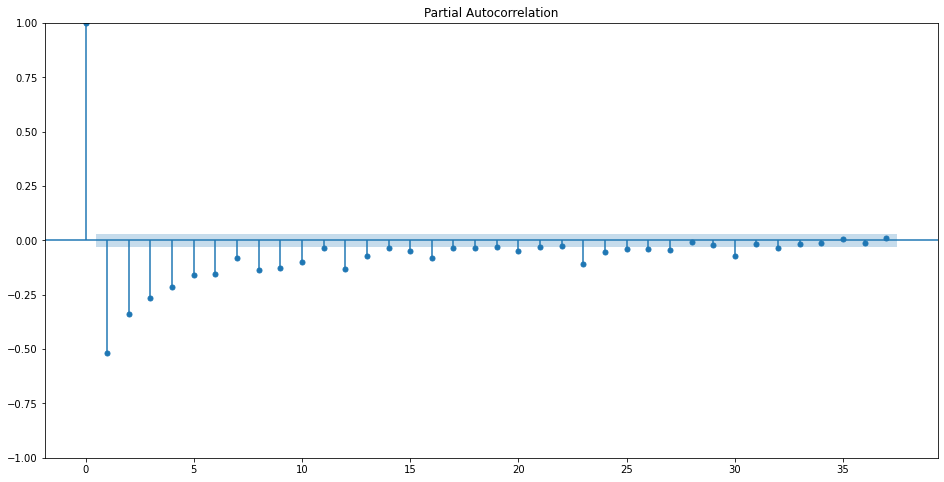

In [109]:
# Utilizing Partial Autocorrelation Function (PACF) plot to find 'p'

fig, ax = plt.subplots(figsize=(16, 8))

plot_pacf(bitcoin_arima_diff['Price'], ax=ax);

The PACF plot has a negative spike at 1.  However, the negative gradually approaches 0.  As a result, I will set *p* to 0 for the ARIMA model.

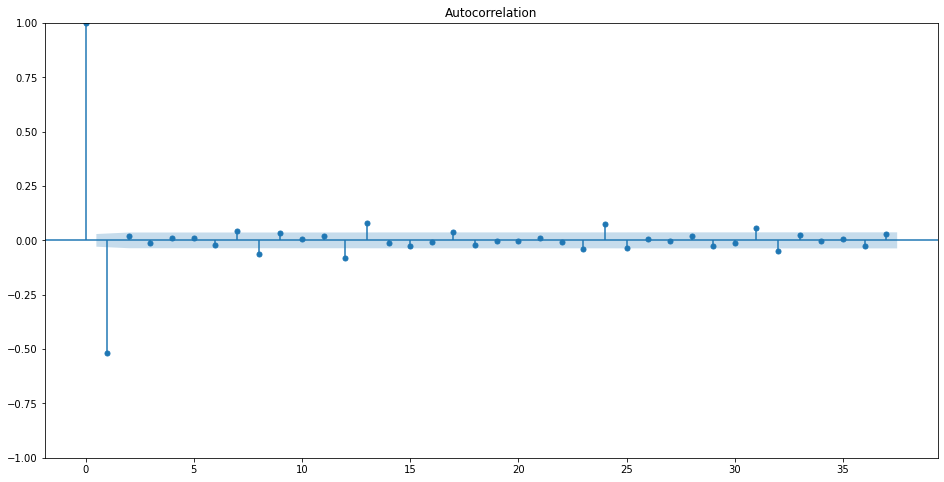

In [110]:
# Utilizing Autocorrelation Function (ACF) plot to find 'q'

fig, ax = plt.subplots(figsize=(16, 8))

plot_acf(bitcoin_arima_diff['Price'], ax=ax);

The ACF plot has a negative spike at 1.  Afterwards, the ACF plot are close to zero.  As a result, I will set *q* to 1 for the ARIMA model.

In [111]:
# Leveraging the "Moving_Average_Train_Test" function to create the train, test split

bitcoin_arima_train, bitcoin_arima_test, bitcoin_arima_train_idx, bitcoin_arima_test_idx = moving_average_train_test(bitcoin_arima)

In [112]:
# Creating ARIMA model for the "Bitcoin_ARIMA" dataframe with the following (p=0, d=2, q=1)

arima_bitcoin_arima = ARIMA(bitcoin_arima_train, order=(0,2,1))

In [113]:
# Fit the model to the ARIMA model to the "Bitcoin_ARIMA" data

arima_bitcoin_arima_result = arima_bitcoin_arima.fit()

In [114]:
# Model Summary of the ARIMA model

arima_bitcoin_arima_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Price   No. Observations:                 4171
Model:                 ARIMA(0, 2, 1)   Log Likelihood              -34700.399
Date:                Thu, 23 Jul 2026   AIC                          69404.798
Time:                        11:36:57   BIC                          69417.469
Sample:                    01-05-2014   HQIC                         69409.280
                         - 06-06-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9998      0.001   -977.980      0.000      -1.002      -0.998
sigma2       9.94e+05   7953.716    124.973      0.000    9.78e+05    1.01e+06
===================================================================================
Ljung-Box (L1) (Q):                  10.98   Jarque-Bera (JB):             29632.02
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):             568.40   Skew:                             0.30
Prob(H) (two-sided):                  0.00   Kurtosis:                        16.05
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [115]:
# Using the ARIMA Model to forecast

prediction_result_arima_bitcoin_arima = arima_bitcoin_arima_result.get_forecast(steps=360)


# Extracting the mean of the prediction results

prediction_result_arima_bitcoin_arima_mean = prediction_result_arima_bitcoin_arima.predicted_mean

In [116]:
# Calculate Root Mean Square Error (RMSE) for the ARIMA Model

rmse_arima_bitcoin_arima = mean_squared_error(bitcoin_arima_test, prediction_result_arima_bitcoin_arima_mean, squared=False)

print(rmse_arima_bitcoin_arima)

25719.22778885091


In [117]:
def plot_model_w_conf_int(Actual_Data, Prediction_Results, Column, Title):

    plt.figure(figsize=(16,8)) # Width, Height in Inches

    # Select the actual values
    actual_values = Actual_Data[Column]
    
    
    # Extract predicted mean and confidence interval
    prediction_mean = Prediction_Results.predicted_mean
    conf_int = Prediction_Results.conf_int()
    
    # Align the forecast index with the test-data index
    prediction_mean = pd.Series(
        prediction_mean.to_numpy(),
        index=actual_values.index
        )
    
    conf_int = pd.DataFrame(
        conf_int.to_numpy(),
        index=actual_values.index
        )
    
    # Actual Test Data
    plt.plot(
        actual_values.index,
        actual_values,
        label='Data')
    
    # Forecast
    plt.plot(
        prediction_mean.index,
        prediction_mean,
        label='Forecast'
        )
    
     # Plot of the Confidence Interval of the Prediction Data
    plt.fill_between(
        conf_int.index,
        conf_int.iloc[:, 0],
        conf_int.iloc[:, 1],
        alpha=0.3,
        label='95% Confidence Interval',
        color='pink'
        )
    
    # Title of the Plot
    plt.title(Title) 
    
    # Label on the x-axis
    plt.xlabel("Date") 
    
    # Label on the y-axis
    plt.ylabel(Column) 
    
    # Legend
    plt.legend()
        
    return plt.show()

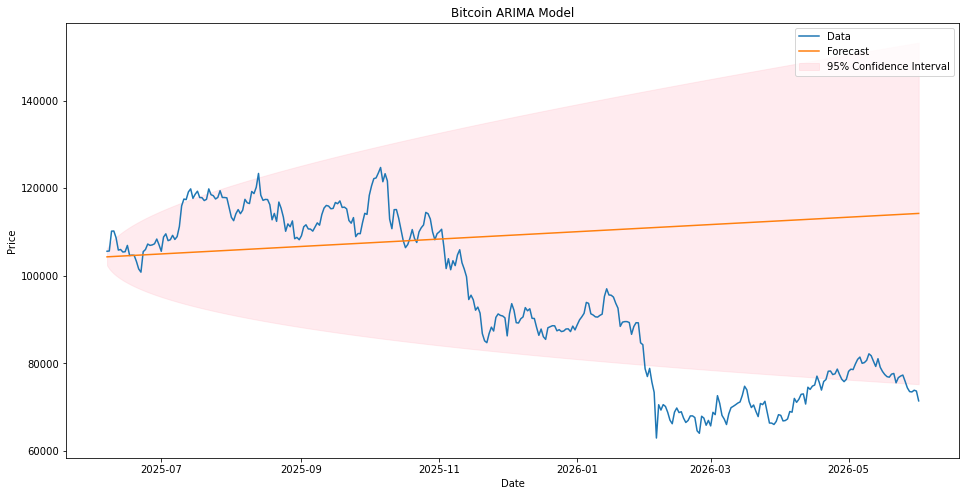

In [118]:
# Plotting the predictions against the actual results for the Bitcoin ARIMA Model

plot_model_w_conf_int(bitcoin_arima_test, prediction_result_arima_bitcoin_arima, 'Price', 'Bitcoin ARIMA Model')

### ARIMA with Log Transformation ###

In [119]:
# Creating a dataframe for ARIMA model with Log Transformation

bitcoin_arima_log = bitcoin_df.copy()

In [120]:
# Checking to determine whether or not the new dataframe has been created

bitcoin_arima_log.head()

,Date,Price
0,2026-06-01,71439.79
1,2026-05-31,73688.05
2,2026-05-30,73867.98
3,2026-05-29,73476.46
4,2026-05-28,73553.92


In [121]:
# Applying Log Transformation to the 'Price' column

bitcoin_arima_log['Price'] = np.log(bitcoin_arima_log['Price'])

In [122]:
# Checking whether or not the log transformation has been applied to the 'Price' column

bitcoin_arima_log.head()

,Date,Price
0,2026-06-01,11.176610
1,2026-05-31,11.207596
2,2026-05-30,11.210035
3,2026-05-29,11.204720
4,2026-05-28,11.205774


In [123]:
# Creating a dataframe of the "bitcoin_arima" dataframe in order to examine the p,d,q variables that are required to create the ARIMA Model

bitcoin_arima_log_diff = bitcoin_arima_log.copy()

In [124]:
# Utilizing the 'date_to_datetime_set_index' function on the 'bitcoin_arima_log' dataframe

bitcoin_arima_log_diff = date_to_datetime_set_index(bitcoin_arima_log_diff, 'Date')

In [125]:
# Examining whether or not the 'date_to_datetime_set_index' function was executed successfully

bitcoin_arima_log_diff.head()

,Price
Date,
2014-01-05,6.838973
2014-01-06,6.859919
2014-01-07,6.687109
2014-01-08,6.736635
2014-01-09,6.741535


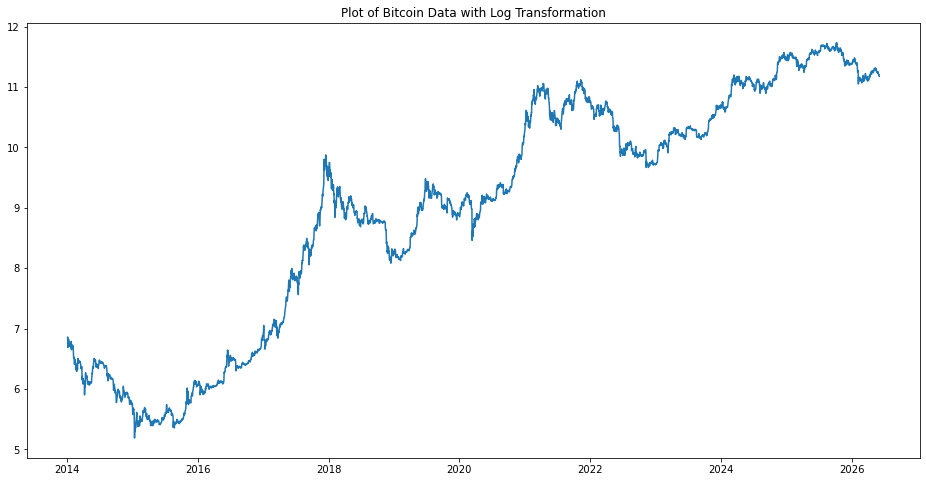

In [126]:
# Examining a plot of the Price column to determine how much to difference the data

plt.figure(figsize=(16, 8))

plt.plot(bitcoin_arima_log_diff['Price'])

plt.title("Plot of Bitcoin Data with Log Transformation")
           
plt.show()

Based on the visual plot, the Bitcoin price increase is not perfectly linear.  However, the plot exhibits characteristics of linearity.  As a result, I will difference the data one time and apply the Dicky Fuller test.

In [127]:
# Applying first-order differencing to the 'Price' column

bitcoin_arima_log_diff['Price'] = bitcoin_arima_log_diff['Price'].diff()

In [128]:
# Examining whether or not the 'Price' column has been differenced

bitcoin_arima_log_diff.head()

,Price
Date,
2014-01-05,NaN
2014-01-06,0.020946
2014-01-07,-0.172811
2014-01-08,0.049526
2014-01-09,0.004901


In [129]:
# Drop the rows with no data in the 'Price' column

bitcoin_arima_log_diff.dropna(inplace=True)

In [130]:
# Examining whether or not the rows with no data in the 'bitcoin_arima_diff' dataframe have been dropped

bitcoin_arima_log_diff.head()

,Price
Date,
2014-01-06,0.020946
2014-01-07,-0.172811
2014-01-08,0.049526
2014-01-09,0.004901
2014-01-10,0.025209


In [131]:
# Performing a Dicky Fuller test to determine whether or not the 'bitcoin_arima_log_dff' dataframe has stationarity

bitcoin_arima_log_diff_adf_result = adfuller(bitcoin_arima_log_diff)

print("ADF Statistic:", bitcoin_arima_log_diff_adf_result[0])
print("p-value:", bitcoin_arima_log_diff_adf_result[1])

ADF Statistic: -69.47336377025854
p-value: 0.0


I performed the Dicky Fuller test.  And the p-value result is 0.0.  Since the p-value result is less than 0.05, statistical significance has been achieved.  In other words, stationarity has been achieved.  As a result, *d* will be set to 1 for the ARIMA model.

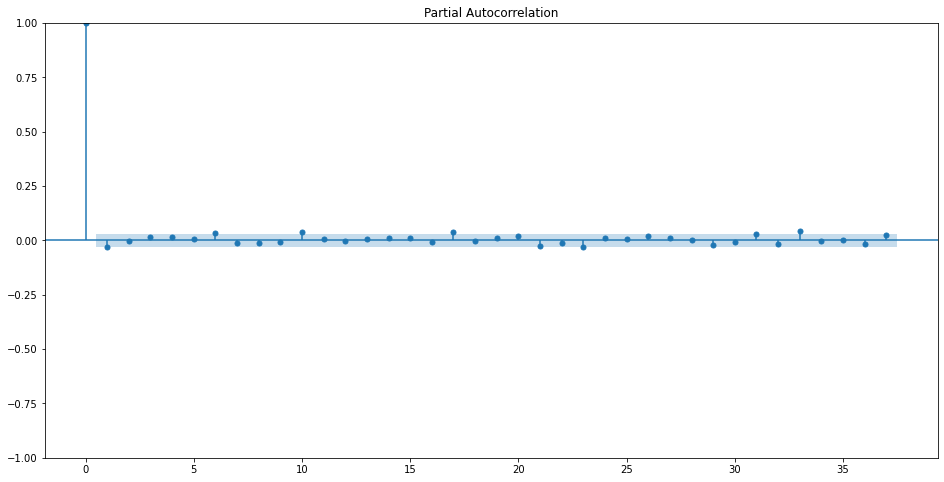

In [132]:
# Utilizing Partial Autocorrelation Function (PACF) plot to find 'p'

fig, ax = plt.subplots(figsize=(16, 8))

plot_pacf(bitcoin_arima_log_diff['Price'], ax=ax);

The PACF plot approaches zero after 0.  As a result, I will set *q* to 0 for the ARIMA model with log transformation.

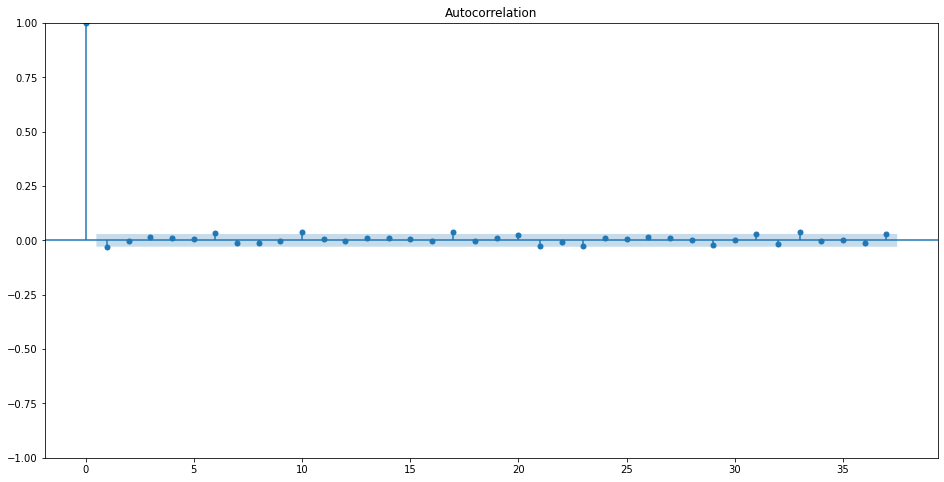

In [133]:
# Utilizing Autocorrelation Function (ACF) plot to find 'q'

fig, ax = plt.subplots(figsize=(16, 8))

plot_acf(bitcoin_arima_log_diff['Price'], ax=ax);

The ACF plot approaches zero after 0.  As a result, I will set *q* to 0 for the ARIMA model with log transformation.

I have finished calcculating the values for the *p*, *d*, and *q* variables.  Based on the work in this section, the ARIMA model with log transformation have *p*, *d*, and *q* values of 0, 1, and 0, respectively.  Theese *p*, *d*, and *q* values are equivalent to the values for a Naive Forecast model.  As a result, I will not pursue creating the ARIMA model with log transformation any further.  

## Auto-ARIMA ##

### Auto-ARIMA ###

In [134]:
# Creating a dataframe for Auto-ARIMA model

bitcoin_auto_arima = bitcoin_df.copy()

In [135]:
# Checking to determine whether or not the new dataframe has been created

bitcoin_auto_arima.head()

,Date,Price
0,2026-06-01,71439.79
1,2026-05-31,73688.05
2,2026-05-30,73867.98
3,2026-05-29,73476.46
4,2026-05-28,73553.92


In [136]:
# Utilizing the 'date_to_datetime_set_index' function on the 'bitcoin_auto_arima' dataframe

#bitcoin_auto_arima = date_to_datetime_set_index(bitcoin_auto_arima, 'Date')

In [137]:
# Examining whether or not the 'date_to_datetime_set_index' function was executed successfully

#bitcoin_auto_arima.head()

In [138]:
# Creating the train and test set for the 'Auto-ARIMA' dataframe

bitcoin_auto_arima_train, bitcoin_auto_arima_test, bitcoin_auto_arima_train_idx, bitcoin_auto_arima_test_idx = moving_average_train_test(bitcoin_auto_arima)

In [139]:
# Creating the 'Bitcoin Auto ARIMA' model

bitcoin_auto_arima_model = pm.auto_arima(bitcoin_auto_arima_train, trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=69409.701, Time=0.31 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=69412.778, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=69403.923, Time=0.17 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=69404.144, Time=0.23 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=69413.362, Time=0.05 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=69405.620, Time=0.23 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=69405.668, Time=0.19 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=69407.671, Time=0.27 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=69404.777, Time=0.08 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0] intercept
Total fit time: 1.611 seconds


In [140]:
bitcoin_auto_arima_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 4171
Model:               SARIMAX(1, 1, 0)   Log Likelihood              -34698.962
Date:                Thu, 23 Jul 2026   AIC                          69403.923
Time:                        11:37:00   BIC                          69422.930
Sample:                    01-05-2014   HQIC                         69410.647
                         - 06-06-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     26.0221     15.471      1.682      0.093      -4.300      56.344
ar.L1         -0.0510      0.007     -6.817      0.000      -0.066      -0.036
sigma2      9.891e+05   7931.237    124.709      0.000    9.74e+05       1e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             29651.59
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):             513.70   Skew:                             0.34
Prob(H) (two-sided):                  0.00   Kurtosis:                        16.05
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Based on the model summary for the Bitcoin Auto ARIMA model, the values for *p*, *d*, and *q* are 1, 1, and 0, respectively.

In [141]:
# Creating the forecast and confidence interval for the Bitcoin Auto-ARIMA Model

bitcoin_auto_arima_n_periods = len(bitcoin_auto_arima_test)

bitcoin_auto_arima_prediction_mean, bitcoin_auto_arima_confidence_interval = bitcoin_auto_arima_model.predict(
    n_periods = bitcoin_auto_arima_n_periods,
    return_conf_int=True,
    alpha=0.05
)

In [142]:
# Calculating the Prediction Mean and Confidence Interval

bitcoin_auto_arima_prediction_mean_pandas = pd.Series(
    bitcoin_auto_arima_prediction_mean,
    index=bitcoin_auto_arima_test.index,
    name='Bitcoin Auto ARIMA Forecast'
)

bitcoin_auto_arima_confidence_interval_pandas = pd.DataFrame(
    bitcoin_auto_arima_confidence_interval,
    index=bitcoin_auto_arima_test.index,
    columns=['Lower Bound', 'Upper Bound']
)

In [143]:
# Calculating RMSE for the "Bitcoin Auto ARIMA" model

rmse_bitcoin_auto_arima = np.sqrt(
    mean_squared_error(
        bitcoin_auto_arima_test['Price'],
        bitcoin_auto_arima_prediction_mean_pandas)
)

print(rmse_bitcoin_auto_arima)

25123.212456732508


In [144]:
# Creating a plot function for the Bitcoin Auto ARIMA model (which is pmdarima output, not Statsmodels)

def plot_auto_arima_forecast(actual_data, prediction_mean, confidence_interval, column, title):
    
    plt.figure(figsize=(16, 8))
    
    actual_values = actual_data[column]
    
    # Actual test data
    
    plt.plot(actual_values.index, actual_values, label='Data')
    
    # Forecast
    
    plt.plot(prediction_mean.index, prediction_mean, label='Forecast')
    
    # 95% Confidence Interval
    
    plt.fill_between(
        confidence_interval.index,
        confidence_interval.iloc[:, 0],
        confidence_interval.iloc[:, 1],
        alpha=0.3,
        label='95% Confidence Interval',
        color='pink')
    
     # Title of the Plot
    plt.title(title) 
    
    # Label on the x-axis
    plt.xlabel("Date") 
    
    # Label on the y-axis
    plt.ylabel(column) 
    
    # Legend
    plt.legend()
        
    return plt.show()

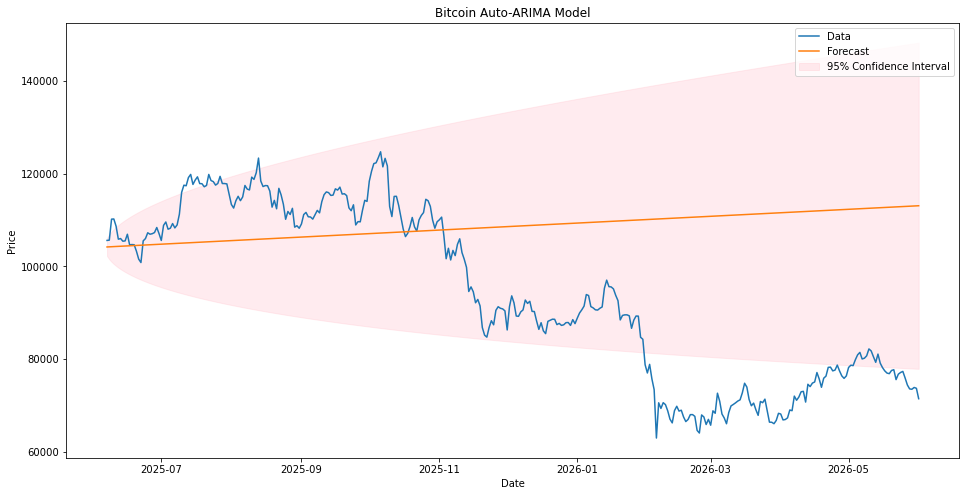

In [145]:
# Plotting the 'Bitcoin Auto-ARIMA' model

plot_auto_arima_forecast(bitcoin_auto_arima_test, 
                         bitcoin_auto_arima_prediction_mean_pandas, 
                         bitcoin_auto_arima_confidence_interval_pandas,
                         'Price',
                         'Bitcoin Auto-ARIMA Model'
                        )

### Auto-ARIMA with Log Transformation ###

In [146]:
# Creating a dataframe for Auto-ARIMA model with Log Transformation

bitcoin_auto_arima_log = bitcoin_df.copy()


In [147]:
# Checking to determine whether or not the new dataframe has been created

bitcoin_auto_arima_log.head()

,Date,Price
0,2026-06-01,71439.79
1,2026-05-31,73688.05
2,2026-05-30,73867.98
3,2026-05-29,73476.46
4,2026-05-28,73553.92


In [148]:
# Applying Log Transformation to the 'Price' column

bitcoin_auto_arima_log['Price'] = np.log(bitcoin_auto_arima_log['Price'])

In [149]:
# Checking whether or not the log transformation has been applied to the 'Price' column

bitcoin_auto_arima_log.head()

,Date,Price
0,2026-06-01,11.176610
1,2026-05-31,11.207596
2,2026-05-30,11.210035
3,2026-05-29,11.204720
4,2026-05-28,11.205774


In [150]:
# Creating the train and test set for the 'Auto-ARIMA' with log Transformation dataframe

bitcoin_auto_arima_log_train, bitcoin_auto_arima_log_test, bitcoin_auto_arima_log_train_idx, bitcoin_auto_arima_log_test_idx = moving_average_train_test(bitcoin_auto_arima_log)

In [151]:
# Creating the 'Bitcoin Auto ARIMA' model with Log Transformation

bitcoin_auto_arima_log_model = pm.auto_arima(bitcoin_auto_arima_log_train, trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-15737.114, Time=1.81 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-15739.606, Time=0.40 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-15741.747, Time=0.26 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-15741.744, Time=0.35 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-15737.635, Time=0.25 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-15739.774, Time=0.34 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-15739.741, Time=0.41 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-15737.766, Time=0.77 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-15739.524, Time=0.17 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0] intercept
Total fit time: 4.777 seconds


In [152]:
bitcoin_auto_arima_log_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 4171
Model:               SARIMAX(1, 1, 0)   Log Likelihood                7873.874
Date:                Thu, 23 Jul 2026   AIC                         -15741.747
Time:                        11:37:05   BIC                         -15722.740
Sample:                    01-05-2014   HQIC                        -15735.024
                         - 06-06-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0012      0.001      1.986      0.047    1.52e-05       0.002
ar.L1         -0.0315      0.009     -3.462      0.001      -0.049      -0.014
sigma2         0.0013   1.06e-05    126.608      0.000       0.001       0.001
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             35822.53
Prob(Q):                              1.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.61   Skew:                            -0.91
Prob(H) (two-sided):                  0.00   Kurtosis:                        17.24
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Based on the model summary for the Bitcoin Auto ARIMA model with log transformation, the values for *p*, *d*, and *q* are 1, 1, and 0, respectively.

In [153]:
# Creating the forecast and confidence interval for the Bitcoin Auto-ARIMA Model with Log Transformation

bitcoin_auto_arima_log_n_periods = len(bitcoin_auto_arima_log_test)

bitcoin_auto_arima_log_prediction_mean, bitcoin_auto_arima_log_confidence_interval = bitcoin_auto_arima_log_model.predict(
    n_periods = bitcoin_auto_arima_log_n_periods,
    return_conf_int=True,
    alpha=0.05
)

In [154]:
# Calculating the Prediction Mean and Confidence Interval

bitcoin_auto_arima_log_prediction_mean_pandas = pd.Series(
    bitcoin_auto_arima_log_prediction_mean,
    index=bitcoin_auto_arima_log_test.index,
    name='Bitcoin Auto ARIMA with Log Transformation Forecast'
)

bitcoin_auto_arima_log_confidence_interval_pandas = pd.DataFrame(
    bitcoin_auto_arima_log_confidence_interval,
    index=bitcoin_auto_arima_log_test.index,
    columns=['Lower Bound', 'Upper Bound']
)

In [155]:
# Calculating RMSE for the "Bitcoin Auto ARIMA" model with Log Transformaton

rmse_bitcoin_auto_arima_log = np.sqrt(
    mean_squared_error(
        bitcoin_auto_arima_log_test['Price'],
        bitcoin_auto_arima_log_prediction_mean_pandas)
)

print(rmse_bitcoin_auto_arima_log)

0.4468661467689942


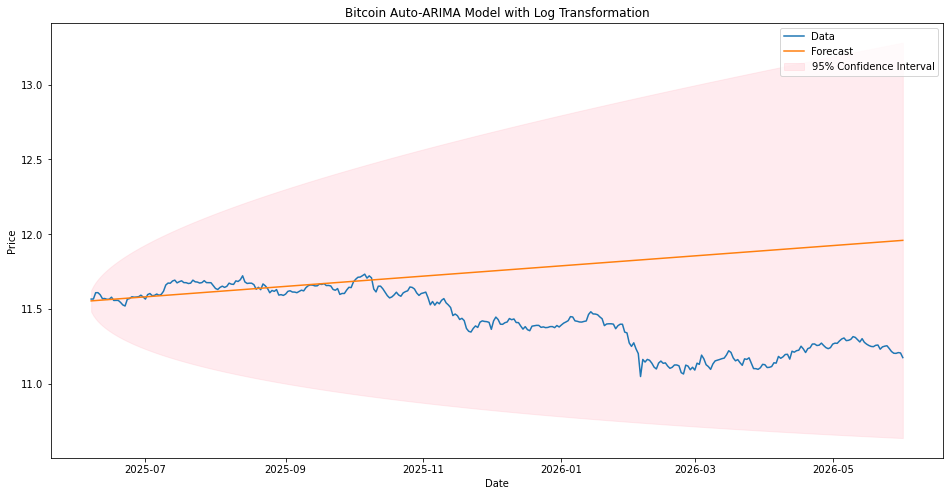

In [156]:
# Plotting the 'Bitcoin Auto-ARIMA' model with Log Transformation

plot_auto_arima_forecast(bitcoin_auto_arima_log_test, 
                         bitcoin_auto_arima_log_prediction_mean_pandas, 
                         bitcoin_auto_arima_log_confidence_interval_pandas,
                         'Price',
                         'Bitcoin Auto-ARIMA Model with Log Transformation'
                        )

# Overall Conclusion and Recommendations

## Overall Conclusion and Recommendations

## Next Steps